# Two-site site-frequency spectra
The two-site (or two-locus) SFS summarizes pairs of linked segregating sites: its entry $(i, j)$ counts pairs of sites, within a genomic-distance window, at which one site has $i$ and the other $j$ derived alleles. Departures from the outer product of the one-dimensional spectrum reflect linkage and non-Kingman genealogies. Setting `two_sfs=True` makes the {class}`~sfsutils.parser.Parser` pair sites within `two_sfs_distance` base pairs and return a square {class}`~sfsutils.spectrum.TwoSFS`.

In [1]:
import matplotlib.pyplot as plt
from sfsutils.settings import Settings

plt.rcParams['figure.figsize'] = [4.4, 3.3]
Settings.disable_pbar = True

In [2]:
import sfsutils as su

vcf = "resources/genome/betula/biallelic.polarized.subset.10000.vcf.gz"

sfs2 = su.Parser(vcf=vcf, n=20, two_sfs=True, two_sfs_distance=1000).parse()

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file


INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Skipped 376 sites without ancestral allele information.
INFO:Parser: Included 9599 out of 10000 sites in total from the VCF file.
INFO:Parser: Counted 855831 site pairs within 1000 bp.


The matrix is symmetric and can be shown as a heatmap; the monomorphic rows and columns are omitted.

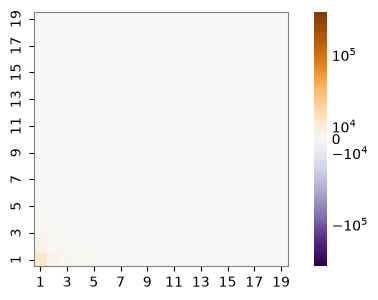

In [3]:
sfs2.plot();

Folding the spectrum (when the ancestral state is unknown) and masking the diagonals are available as for any {class}`~sfsutils.spectrum.TwoSFS`.

In [4]:
sfs2.fold().is_folded()

np.True_

## Branch-length covariance and correlation
The pair counts also resolve, by derived-allele-count class, how the two linked sites covary. {meth}`~sfsutils.spectrum.TwoSFS.cov` returns $C[i, j] = P(i, j) - P(i)\,P(j)$, the excess with which frequency classes $i$ and $j$ co-occur at linked sites over independence, and {meth}`~sfsutils.spectrum.TwoSFS.corr` standardizes it to the cross-locus Pearson correlation of class membership, $R[i, j] \in [-1, 1]$. Both are computed from the segregating interior alone (see {meth}`~sfsutils.spectrum.TwoSFS.interior`), so they ignore the monomorphic bins entirely and are unchanged by any {class}`~sfsutils.parser.TargetSiteCounter`. Each is itself a {class}`~sfsutils.spectrum.TwoSFS` and plots like any other.

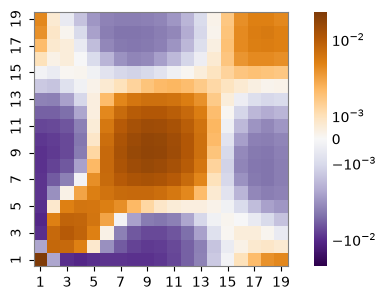

In [5]:
corr = sfs2.corr()
corr.plot();

Because they read only the interior, `cov` and `corr` are well-defined even for a SNP-only spectrum with no monomorphic pairs, and adding monomorphic mass leaves them untouched; the only degenerate input is an empty interior.